# 데이터과학 팀프로젝트 4조 - 장세창 모델링 최종 통합본

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

## 데이터 전처리 함수 정의

In [5]:
def preprocess_youth_dataset_full(filepath, model_type='rf'):
    df = pd.read_csv(filepath, encoding='cp949')
    df.columns = df.columns.str.strip()
    df['Target'] = df['우울증상 유병 여부'].map({1: 0, 2: 1})
    y = df['Target']
    drop_cols = ['우울증상 유병 여부', 'Target', '최근 1년 소진(번아웃) 경험 여부']
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    X = X.copy()
    if '경제활동상태' in X.columns:
        X['현재 근무 여부'] = X['경제활동상태'].apply(lambda x: 1 if x == 1 else 0)
    else:
        X['현재 근무 여부'] = 0
    ordinal_mappings = {
        '현재 흡연 여부': {4: 1, 3: 2, 2: 3, 1: 4},
        '최근 1년간 음주 빈도': {7: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6},
        '외식 또는 매식 빈도': {5: 0, 4: 1, 3: 2, 2: 3, 1: 4},
        '일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다': {
            5: 1, 4: 2, 3: 3, 2: 4, 1: 5
        },
        '정치에 대한 관심 정도': {4: 1, 3: 2, 2: 3, 1: 4},
        '외출 빈도': {8: 1, 7: 2, 6: 3, 5: 4, 4: 5, 3: 6, 2: 7, 1: 8},
        '주관적 계층 인식': {5: 1, 4: 2, 3: 3, 2: 4, 1: 5}
    }
    standard_ordinal_cols = [
        '연령별', '가구원수', '최종학력', '음주 정도', '평소 규칙적 운동 여부',
        '고용 계약 기간', '총 고용 예상 기간', '지난 주 일자리 종사자 수', '재직 기간(범위)'
    ]
    def apply_ordinal_transform(data):
        data = data.copy()
        if '정규근로시간 외 추가 근무' in data.columns:
            data['정규근로시간 외 추가 근무'] = data['정규근로시간 외 추가 근무'].map(
                {6: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 7: 1}
            ).fillna(0)
        if '정규 근로일 외 휴일 근무 횟수' in data.columns:
            data['정규 근로일 외 휴일 근무 횟수'] = data['정규 근로일 외 휴일 근무 횟수'].map(
                {0: 1, 1: 2, 2: 3}
            ).fillna(0)
        for col, mapping in ordinal_mappings.items():
            if col in data.columns:
                data[col] = data[col].fillna(0)
                data[col] = data[col].map(mapping).fillna(0)
        for col in standard_ordinal_cols:
            if col in data.columns:
                data[col] = data[col].fillna(0)
        return data
    X = apply_ordinal_transform(X)
    nominal_cols = [
        '성별', '지역별', '장애여부','귀하의 현재 재학 상태를 응답해 주십시오.', '(복수 응답) 가구유형(1)',
        '국민기초생활보장제도(또는 맞춤형 급여) 수급 여부 및 경험', '돌봄 필요 가구원 유무', '혼인 상태',
        '부모 동거 여부', '공공 임대 주택 거주 경험', '현재 주거 점유 형태', '최근 1달 동안 같이 식사한 사람',
        '경제활동상태', '지난 주 수입을 목적으로 1시간 이상 일한 경험', '지난 주 종사상 지위',
        '고용 계약 기간 유무', '주휴 수당 수급 여부', '정규근로시간 외 추가 근무 시 추가 수당 수급 여부',
        '정규근로일 외 휴일 근무 시 추가 수당 수급 여부',
        '장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 가족^ 친척',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 – 이외',
        '현재 연애 여부(유배우 포함)', '향후 결혼 계획(유배우 포함)',
        '금융 채무 불이행자(신용불량자)에 해당 여부',
        '현재 근무 여부'
    ]
    valid_nominal_cols = [col for col in nominal_cols if col in X.columns]
    for col in valid_nominal_cols:
        X[col] = X[col].fillna('해당없음').astype(str)
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_ohe = pd.DataFrame(
        ohe.fit_transform(X[valid_nominal_cols]),
        columns=ohe.get_feature_names_out(valid_nominal_cols),
        index=X.index
    )
    ohe_cols = list(X_ohe.columns)
    robust_cols = ['청년 연간소득 - 총 소득', '청년 기준 부채 총액', '청년 기준 재산총액']
    standard_cols = ['월 평균 총생활비']
    for col in robust_cols + standard_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)
            X[col] = np.log1p(X[col])
    X_non_nominal = X.drop(columns=valid_nominal_cols, errors='ignore')
    X_final = pd.concat([X_non_nominal, X_ohe], axis=1)
    if model_type == 'lr':
        valid_robust_cols = [col for col in robust_cols if col in X_final.columns]
        if valid_robust_cols:
            r_scaler = RobustScaler()
            X_final[valid_robust_cols] = r_scaler.fit_transform(X_final[valid_robust_cols])
        valid_standard_cols = [
            col for col in standard_cols + standard_ordinal_cols + list(ordinal_mappings.keys())
            if col in X_final.columns and col not in valid_robust_cols and col not in ohe_cols
        ]
        if valid_standard_cols:
            s_scaler = StandardScaler()
            X_final[valid_standard_cols] = s_scaler.fit_transform(X_final[valid_standard_cols])
    return X_final, y

def preprocess_youth_dataset_no_work(filepath, model_type='lr'):
    df = pd.read_csv(filepath, encoding='cp949')
    df.columns = df.columns.str.strip()
    df['Target'] = df['우울증상 유병 여부'].map({1: 0, 2: 1})
    y = df['Target']
    if '경제활동상태' in df.columns:
        df['현재 근무 여부'] = df['경제활동상태'].apply(lambda x: 1 if x == 1 else 0)
    else:
        df['현재 근무 여부'] = 0
    work_related_cols = [
        '경제활동상태', '지난 주 수입을 목적으로 1시간 이상 일한 경험', '지난 주 종사상 지위',
        '고용 계약 기간 유무', '주휴 수당 수급 여부', '정규근로시간 외 추가 근무 시 추가 수당 수급 여부',
        '정규근로일 외 휴일 근무 시 추가 수당 수급 여부', '장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)',
        '고용 계약 기간', '총 고용 예상 기간', '지난 주 일자리 종사자 수', '재직 기간(범위)',
        '정규근로시간 외 추가 근무', '정규 근로일 외 휴일 근무 횟수',
        '일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다'
    ]
    drop_cols = ['우울증상 유병 여부', 'Target', '최근 1년 소진(번아웃) 경험 여부'] + work_related_cols
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    X = X.copy()
    ordinal_mappings = {
        '현재 흡연 여부': {4: 1, 3: 2, 2: 3, 1: 4},
        '최근 1년간 음주 빈도': {7: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6},
        '외식 또는 매식 빈도': {5: 0, 4: 1, 3: 2, 2: 3, 1: 4},
        '정치에 대한 관심 정도': {4: 1, 3: 2, 2: 3, 1: 4},
        '외출 빈도': {8: 1, 7: 2, 6: 3, 5: 4, 4: 5, 3: 6, 2: 7, 1: 8},
        '주관적 계층 인식': {5: 1, 4: 2, 3: 3, 2: 4, 1: 5}
    }
    standard_ordinal_cols = ['연령별', '가구원수', '최종학력', '음주 정도', '평소 규칙적 운동 여부']
    for col, mapping in ordinal_mappings.items():
        if col in X.columns:
            X[col] = X[col].fillna(0)
            X[col] = X[col].map(mapping).fillna(0)
    for col in standard_ordinal_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)
    nominal_cols = [
        '성별', '지역별', '장애여부', '귀하의 현재 재학 상태를 응답해 주십시오.', '(복수 응답) 가구유형(1)',
        '국민기초생활보장제도(또는 맞춤형 급여) 수급 여부 및 경험', '돌봄 필요 가구원 유무', '혼인 상태',
        '부모 동거 여부', '공공 임대 주택 거주 경험', '현재 주거 점유 형태', '최근 1달 동안 같이 식사한 사람',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 가족^ 친척',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 – 이외',
        '현재 연애 여부(유배우 포함)', '향후 결혼 계획(유배우 포함)',
        '금융 채무 불이행자(신용불량자)에 해당 여부',
        '현재 근무 여부'
    ]
    valid_nominal_cols = [col for col in nominal_cols if col in X.columns]
    for col in valid_nominal_cols:
        X[col] = X[col].fillna('해당없음').astype(str)
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_ohe = pd.DataFrame(
        ohe.fit_transform(X[valid_nominal_cols]),
        columns=ohe.get_feature_names_out(valid_nominal_cols),
        index=X.index
    )
    ohe_cols = list(X_ohe.columns)
    robust_cols = ['청년 연간소득 - 총 소득', '청년 기준 부채 총액', '청년 기준 재산총액']
    standard_cols = ['월 평균 총생활비']
    for col in robust_cols + standard_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)
            X[col] = np.log1p(X[col])
    X_non_nominal = X.drop(columns=valid_nominal_cols, errors='ignore')
    X_final = pd.concat([X_non_nominal, X_ohe], axis=1)
    if model_type == 'lr':
        valid_robust_cols = [col for col in robust_cols if col in X_final.columns]
        if valid_robust_cols:
            r_scaler = RobustScaler()
            X_final[valid_robust_cols] = r_scaler.fit_transform(X_final[valid_robust_cols])
        valid_standard_cols = [
            col for col in standard_cols + standard_ordinal_cols + list(ordinal_mappings.keys())
            if col in X_final.columns and col not in valid_robust_cols and col not in ohe_cols
        ]
        if valid_standard_cols:
            s_scaler = StandardScaler()
            X_final[valid_standard_cols] = s_scaler.fit_transform(X_final[valid_standard_cols])
    return X_final, y

## 1. Random Forest 분석

### 1. 기본 모델 학습

In [6]:
filepath = '2024_Youth_Life_Survey.csv'
X_rf, y_rf = preprocess_youth_dataset_full(filepath, model_type='rf')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_def = RandomForestClassifier(random_state=42, n_jobs=-1)

val_probs_rf_def = np.zeros(len(y_rf))
for train_idx, val_idx in skf.split(X_rf, y_rf):
    rf_def.fit(X_rf.iloc[train_idx], y_rf.iloc[train_idx])
    val_probs_rf_def[val_idx] = rf_def.predict_proba(X_rf.iloc[val_idx])[:, 1]

### 2. 기본 모델 평가값 출력

In [7]:
y_pred_rf_def = (val_probs_rf_def >= 0.50).astype(int)
print("[Random Forest Default Metrics]")
print(f"Accuracy : {accuracy_score(y_rf, y_pred_rf_def):.4f}")
print(f"Precision: {precision_score(y_rf, y_pred_rf_def, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_rf, y_pred_rf_def, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_rf, y_pred_rf_def, zero_division=0):.4f}")

[Random Forest Default Metrics]
Accuracy : 0.9089
Precision: 0.6778
Recall   : 0.0434
F1-Score : 0.0815


### 3. Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

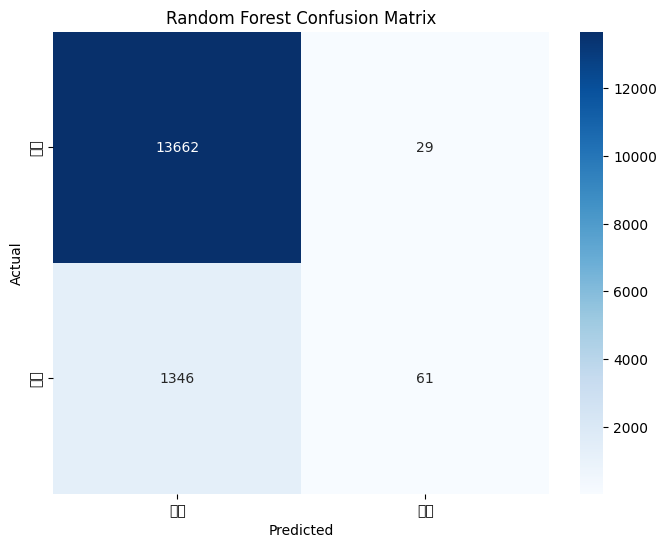

In [8]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_rf, y_pred_rf_def), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 4. 하이퍼파라미터 튜닝을 위한 서치

In [9]:
max_depths = [8, 10, 12, None]
min_samples_splits = [2, 5, 10]
n_estimators_list = [100, 200]
grid_results = []
for md in max_depths:
    for mss in min_samples_splits:
        for ne in n_estimators_list:
            probs = np.zeros(len(y_rf))
            clf = RandomForestClassifier(n_estimators=ne, max_depth=md, min_samples_split=mss, class_weight='balanced', random_state=42, n_jobs=-1)
            for train_idx, val_idx in skf.split(X_rf, y_rf):
                clf.fit(X_rf.iloc[train_idx], y_rf.iloc[train_idx])
                probs[val_idx] = clf.predict_proba(X_rf.iloc[val_idx])[:, 1]
            pred = (probs >= 0.21).astype(int)
            f1 = f1_score(y_rf, pred, zero_division=0)
            grid_results.append((md, mss, ne, f1))
df_grid = pd.DataFrame(grid_results, columns=['max_depth', 'min_samples_split', 'n_estimators', 'F1-Score'])
best_row = df_grid.loc[df_grid['F1-Score'].idxmax()]
print("[Optimal Parameter Found]")
print(best_row)

[Optimal Parameter Found]
max_depth                   NaN
min_samples_split      2.000000
n_estimators         200.000000
F1-Score               0.391439
Name: 19, dtype: float64


### 5. 가장 좋은 모델의 평가값 출력

In [55]:
best_rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1)
val_probs_rf_best = np.zeros(len(y_rf))
for train_idx, val_idx in skf.split(X_rf, y_rf):
    best_rf.fit(X_rf.iloc[train_idx], y_rf.iloc[train_idx])
    val_probs_rf_best[val_idx] = best_rf.predict_proba(X_rf.iloc[val_idx])[:, 1]
y_pred_rf_best = (val_probs_rf_best >= 0.23).astype(int)
print("[Random Forest Tuned Optimal Metrics (Threshold=0.23)]")
print(f"Accuracy : {accuracy_score(y_rf, y_pred_rf_best):.4f}")
print(f"Precision: {precision_score(y_rf, y_pred_rf_best, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_rf, y_pred_rf_best, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_rf, y_pred_rf_best, zero_division=0):.4f}")

[Random Forest Tuned Optimal Metrics (Threshold=0.23)]
Accuracy : 0.8536
Precision: 0.3217
Recall   : 0.5153
F1-Score : 0.3961


### 6. Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

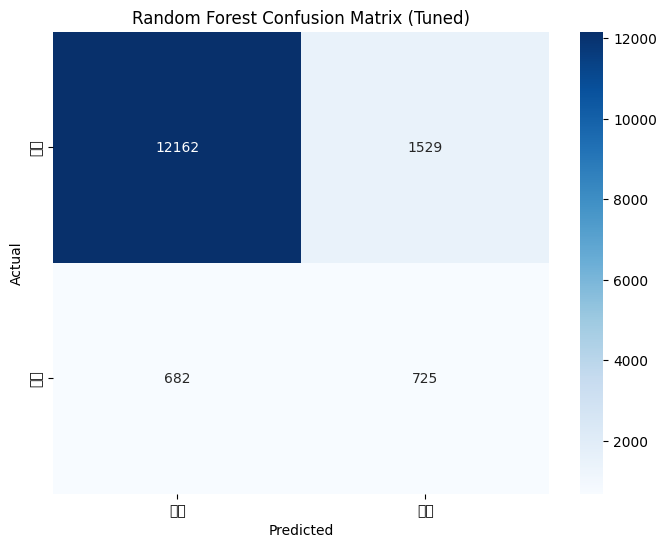

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_rf, y_pred_rf_best), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Random Forest Confusion Matrix (Tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 7. 피처 중요도 출력

/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/109866405.py:11: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


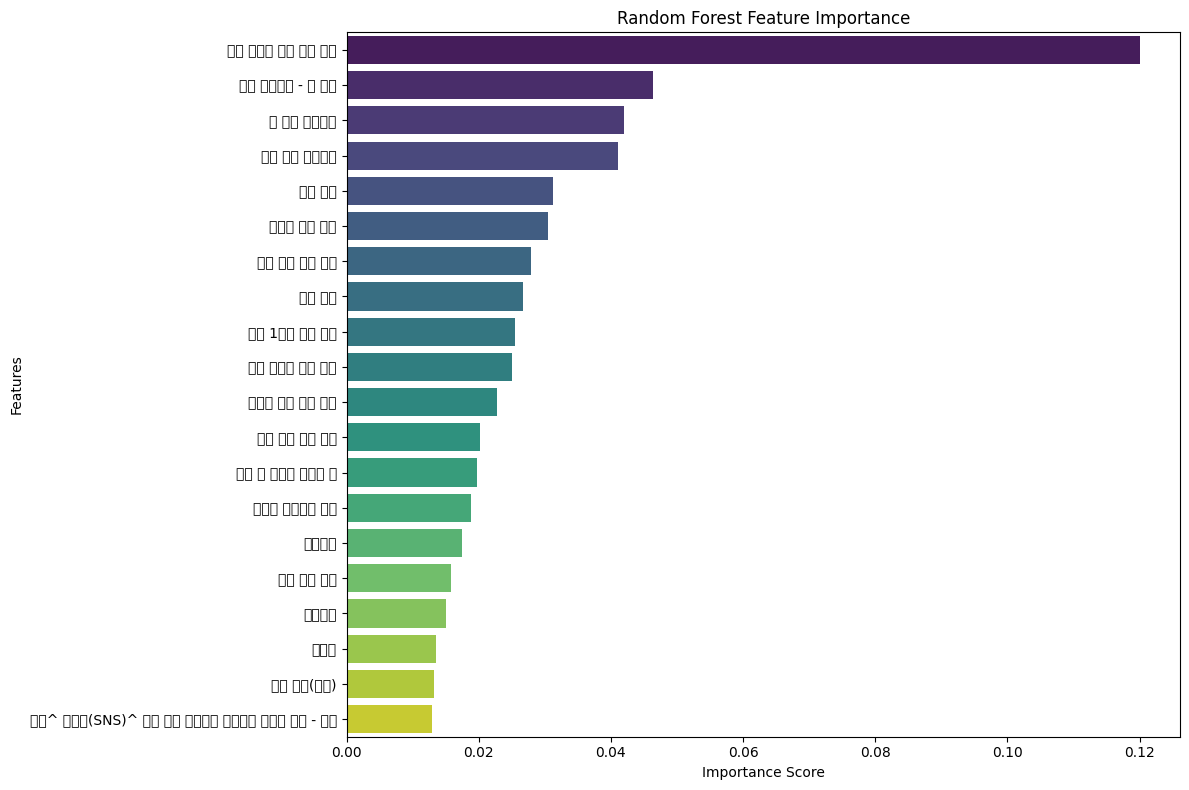

In [57]:
best_rf.fit(X_rf, y_rf)
df_imp = pd.DataFrame({'Feature': X_rf.columns, 'Importance': best_rf.feature_importances_})
df_imp = df_imp.rename(columns={'일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다': '일자리 불안정성 정도'})
df_imp['Feature'] = df_imp['Feature'].replace('일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다', '일자리 불안정성 정도')
df_imp = df_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_imp.head(20), palette='viridis', hue='Feature', legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## II. Logistic Regression 분석 (전체 컬럼 버전)

### 8. Logistic Regression 기본모델 학습

In [58]:
X_lr, y_lr = preprocess_youth_dataset_full(filepath, model_type='lr')
lr_def = LogisticRegression(max_iter=3000, random_state=42)
val_probs_lr_def = np.zeros(len(y_lr))
for train_idx, val_idx in skf.split(X_lr, y_lr):
    lr_def.fit(X_lr.iloc[train_idx], y_lr.iloc[train_idx])
    val_probs_lr_def[val_idx] = lr_def.predict_proba(X_lr.iloc[val_idx])[:, 1]

### 9. 기본모델 평가값 출력

In [59]:
y_pred_lr_def = (val_probs_lr_def >= 0.50).astype(int)
print("[Logistic Regression Default Metrics]")
print(f"Accuracy : {accuracy_score(y_lr, y_pred_lr_def):.4f}")
print(f"Precision: {precision_score(y_lr, y_pred_lr_def, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_lr, y_pred_lr_def, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_lr, y_pred_lr_def, zero_division=0):.4f}")

[Logistic Regression Default Metrics]
Accuracy : 0.9114
Precision: 0.5926
Recall   : 0.1592
F1-Score : 0.2510


### 10. Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

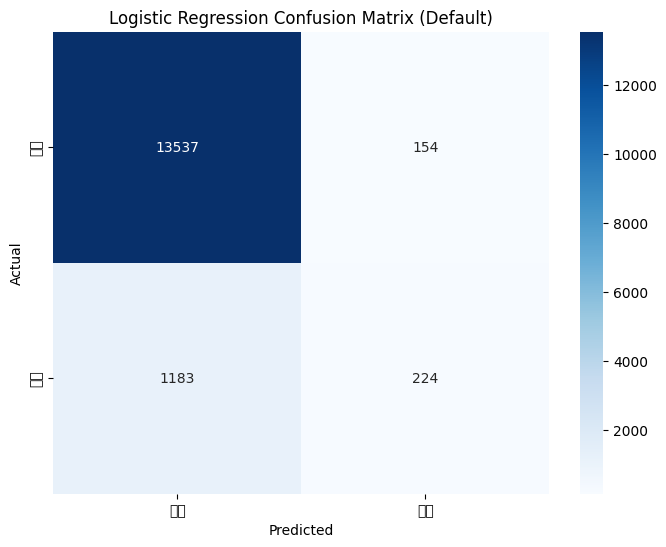

In [60]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_lr, y_pred_lr_def), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Logistic Regression Confusion Matrix (Default)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 11. 하이퍼파라미터 서치 후 가장좋은 모델의 평가값 출력

In [61]:
best_lr = LogisticRegression(C=0.01, max_iter=3000, class_weight='balanced', random_state=42)
val_probs_lr_best = np.zeros(len(y_lr))
for train_idx, val_idx in skf.split(X_lr, y_lr):
    best_lr.fit(X_lr.iloc[train_idx], y_lr.iloc[train_idx])
    val_probs_lr_best[val_idx] = best_lr.predict_proba(X_lr.iloc[val_idx])[:, 1]
y_pred_lr_best = (val_probs_lr_best >= 0.69).astype(int)
print("[Logistic Regression Tuned Optimal Metrics (Threshold=0.69)]")
print(f"Accuracy : {accuracy_score(y_lr, y_pred_lr_best):.4f}")
print(f"Precision: {precision_score(y_lr, y_pred_lr_best, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_lr, y_pred_lr_best, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_lr, y_pred_lr_best, zero_division=0):.4f}")

[Logistic Regression Tuned Optimal Metrics (Threshold=0.69)]
Accuracy : 0.8672
Precision: 0.3470
Recall   : 0.4819
F1-Score : 0.4035


### 12. Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

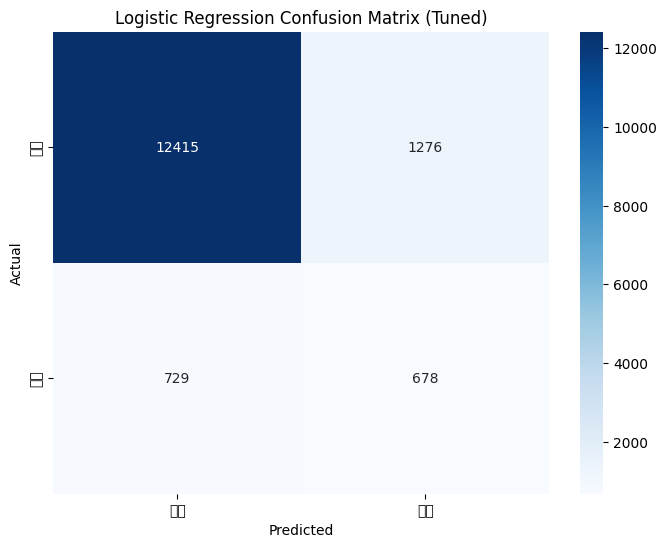

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_lr, y_pred_lr_best), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Logistic Regression Confusion Matrix (Tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 13. 피처 중요도 출력

/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/259761626.py:33: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


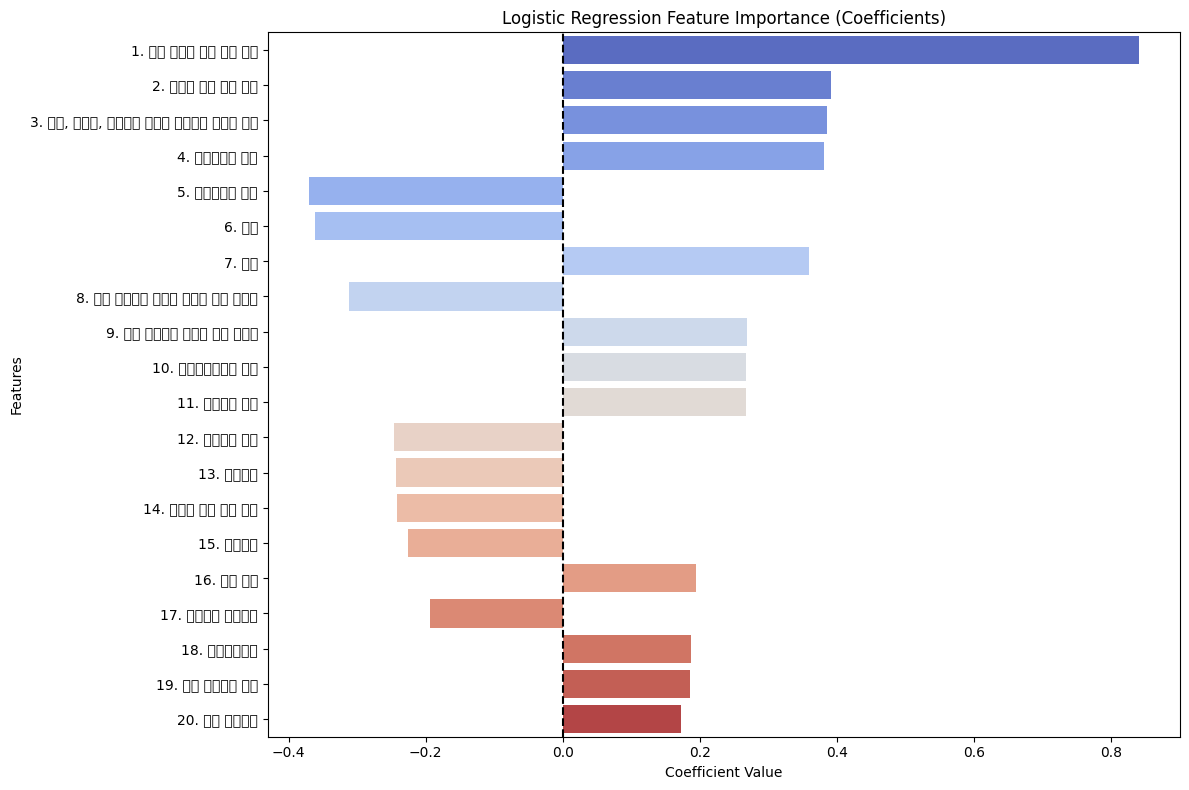

In [63]:
best_lr.fit(X_lr, y_lr)
df_coef = pd.DataFrame({'Feature': X_lr.columns, 'Coefficient': best_lr.coef_[0], 'Abs_Coefficient': np.abs(best_lr.coef_[0])})
df_coef = df_coef.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)
feature_mapping = {
    "평소 본인에 대한 건강 인식": "1. 평소 본인에 대한 건강 인식",
    "장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)_1.0": "2. 장시간 근로 경험 있음",
    "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 이외": "3. 대면, 인터넷, 전화등의 방으로 교류하는 사람의 유무",
    "지역별_23": "4. 인천광역시 거주",
    "지역별_24": "5. 광주광역시 거주",
    "성별_1": "6. 남자",
    "성별_2": "7. 여자",
    "최근 1달 동안 같이 식사한 사람_1": "8. 최근 한달동안 대체로 가족과 함께 식사함",
    "최근 1달 동안 같이 식사한 사람_3": "9. 최근 한달동안 대체로 혼자 식사함",
    "지역별_29": "10. 세종특별자치시 거주",
    "지역별_33": "11. 충청북도 거주",
    "지역별_35": "12. 전라북도 거주",
    "재직 기간(범위)": "13. 재직기간",
    "장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)_2.0": "14. 장시간 근로 경험 없음",
    "외출 빈도": "15. 외출빈도",
    "청년 기준 부채 총액": "16. 부채 총액",
    "(복수 응답) 가구유형(1)_3": "17. 일반적인 가구유형",
    "(복수 응답) 가구유형(1)_2": "18. 자립준비청년",
    "향후 결혼 계획(유배우 포함)_2": "19. 향후 결혼계획 없음",
    "현재 흡연 여부": "20. 현재 흡연여부"
}
df_coef['Feature'] = df_coef['Feature'].map(lambda x: feature_mapping.get(x, x))
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=df_coef.head(20), palette='coolwarm', hue='Feature', legend=False)
plt.title("Logistic Regression Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## 3. Logistic Regression 분석 (근무 관련 변수 제외 버전)

### No-Work 기본모델 학습 및 점수 출력

In [64]:
X_nowork, y_nowork = preprocess_youth_dataset_no_work(filepath, model_type='lr')
lr_nowork_def = LogisticRegression(max_iter=3000, random_state=42)
val_probs_nowork_def = np.zeros(len(y_nowork))
for train_idx, val_idx in skf.split(X_nowork, y_nowork):
    lr_nowork_def.fit(X_nowork.iloc[train_idx], y_nowork.iloc[train_idx])
    val_probs_nowork_def[val_idx] = lr_nowork_def.predict_proba(X_nowork.iloc[val_idx])[:, 1]

y_pred_nowork_def = (val_probs_nowork_def >= 0.50).astype(int)
print("[Logistic Regression No-Work Default Metrics]")
print(f"Accuracy : {accuracy_score(y_nowork, y_pred_nowork_def):.4f}")
print(f"Precision: {precision_score(y_nowork, y_pred_nowork_def, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_nowork, y_pred_nowork_def, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_nowork, y_pred_nowork_def, zero_division=0):.4f}")

[Logistic Regression No-Work Default Metrics]
Accuracy : 0.9126
Precision: 0.6333
Recall   : 0.1485
F1-Score : 0.2406


### No-Work 기본모델 Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

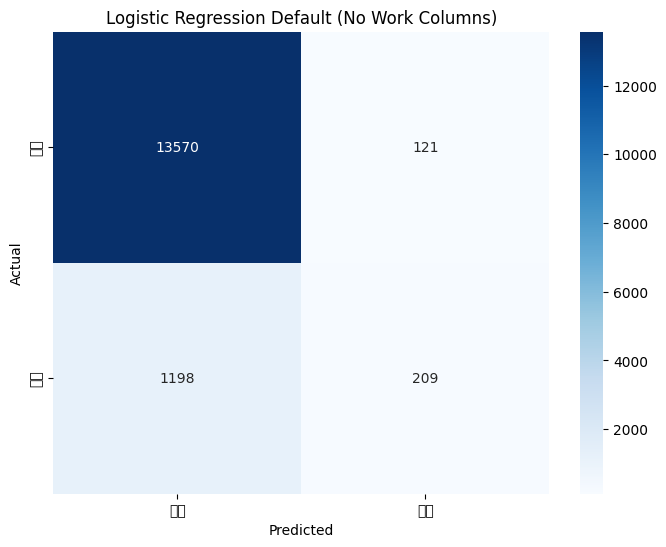

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_nowork, y_pred_nowork_def), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Logistic Regression Default (No Work Columns)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### No-Work 하이퍼파라미터 탐색 후 학습 및 점수 출력

In [66]:
best_lr_nowork = LogisticRegression(C=0.001, max_iter=3000, class_weight='balanced', random_state=42)
val_probs_nowork_best = np.zeros(len(y_nowork))
for train_idx, val_idx in skf.split(X_nowork, y_nowork):
    best_lr_nowork.fit(X_nowork.iloc[train_idx], y_nowork.iloc[train_idx])
    val_probs_nowork_best[val_idx] = best_lr_nowork.predict_proba(X_nowork.iloc[val_idx])[:, 1]

y_pred_nowork_best = (val_probs_nowork_best >= 0.62).astype(int)
print("[Logistic Regression No-Work Tuned Optimal Metrics (Threshold=0.62)]")
print(f"Accuracy : {accuracy_score(y_nowork, y_pred_nowork_best):.4f}")
print(f"Precision: {precision_score(y_nowork, y_pred_nowork_best, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_nowork, y_pred_nowork_best, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_nowork, y_pred_nowork_best, zero_division=0):.4f}")

[Logistic Regression No-Work Tuned Optimal Metrics (Threshold=0.62)]
Accuracy : 0.8614
Precision: 0.3349
Recall   : 0.4947
F1-Score : 0.3994


### No-Work 튜닝모델 Confusion Matrix 출력

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{H

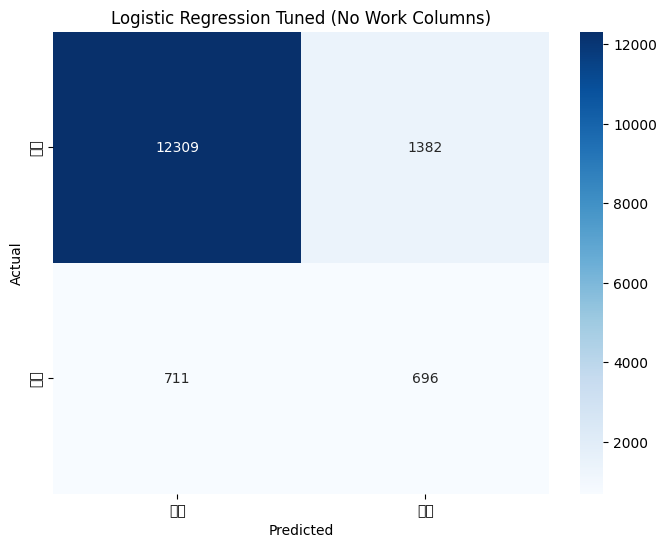

In [67]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_nowork, y_pred_nowork_best), annot=True, fmt='d', cmap='Blues', xticklabels=['없음', '있음'], yticklabels=['없음', '있음'])
plt.title("Logistic Regression Tuned (No Work Columns)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### No-Work 피처 중요도 출력

/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2589/627066010.py:30: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


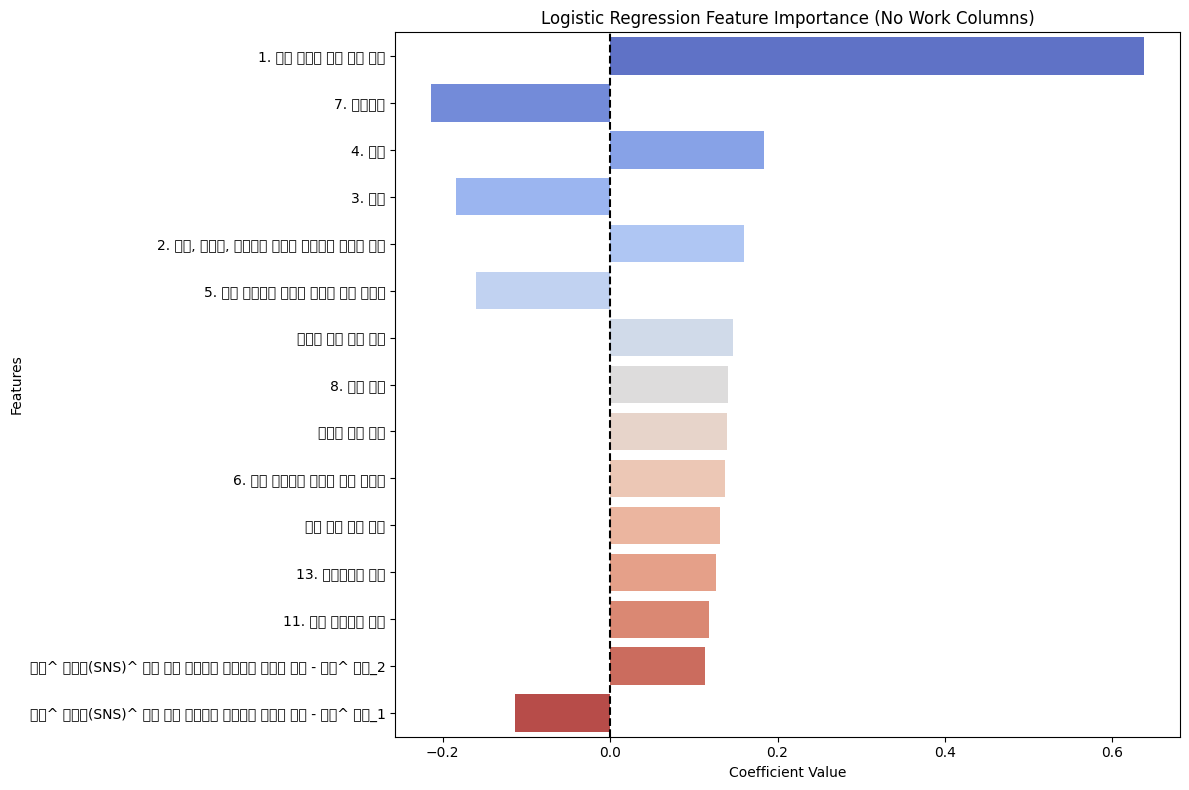

In [68]:
best_lr_nowork.fit(X_nowork, y_nowork)
df_coef_nowork = pd.DataFrame({'Feature': X_nowork.columns, 'Coefficient': best_lr_nowork.coef_[0], 'Abs_Coefficient': np.abs(best_lr_nowork.coef_[0])})
df_coef_nowork = df_coef_nowork.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)
feature_mapping_nowork = {
    "평소 본인에 대한 건강 인식": "1. 평소 본인에 대한 건강 인식",
    "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 이외": "2. 대면, 인터넷, 전화등의 방으로 교류하는 사람의 유무",
    "성별_1": "3. 남자",
    "성별_2": "4. 여자",
    "최근 1달 동안 같이 식사한 사람_1": "5. 최근 한달동안 대체로 가족과 함께 식사함",
    "최근 1달 동안 같이 식사한 사람_3": "6. 최근 한달동안 대체로 혼자 식사함",
    "외출 빈도": "7. 외출빈도",
    "청년 기준 부채 총액": "8. 부채 총액",
    "(복수 응답) 가구유형(1)_3": "9. 일반적인 가구유형",
    "(복수 응답) 가구유형(1)_2": "10. 자립준비청년",
    "향후 결혼 계획(유배우 포함)_2": "11. 향후 결혼계획 없음",
    "현재 흡연 여부": "12. 현재 흡연여부",
    "지역별_23": "13. 인천광역시 거주",
    "지역별_24": "14. 광주광역시 거주",
    "지역별_29": "15. 세종특별자치시 거주",
    "지역별_33": "16. 충청북도 거주",
    "지역별_35": "17. 전라북도 거주"
}
df_coef_nowork['Feature'] = df_coef_nowork['Feature'].map(lambda x: feature_mapping_nowork.get(x, x))
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=df_coef_nowork.head(15), palette='coolwarm', hue='Feature', legend=False)
plt.title("Logistic Regression Feature Importance (No Work Columns)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## 4. 3개 모델 최종 ROC 비교 분석

### 14. 3개 모델 ROC Curve 비교 그래프 출력

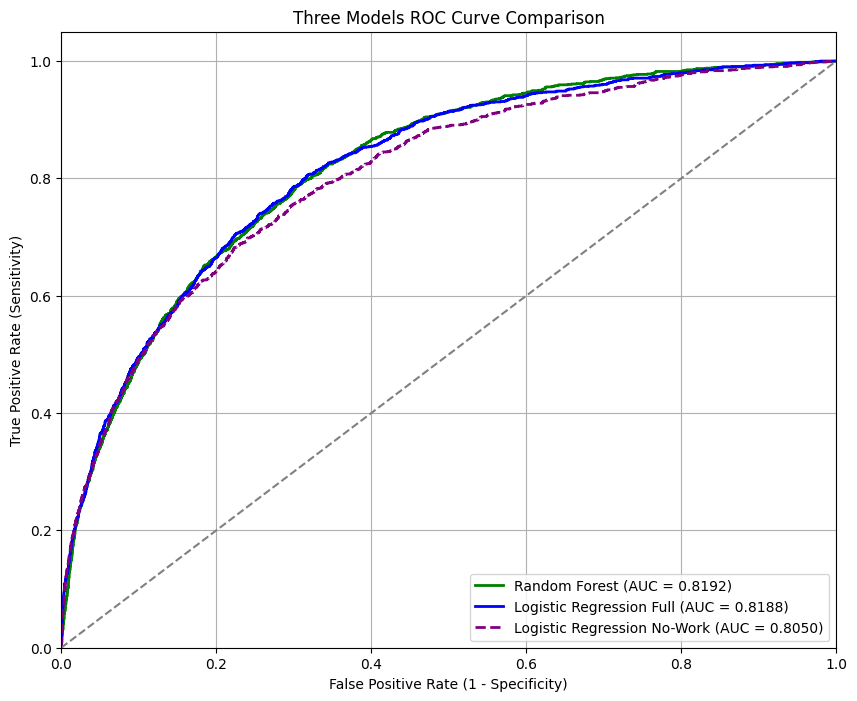

In [69]:
fpr_rf, tpr_rf, _ = roc_curve(y_rf, val_probs_rf_best)
fpr_lr_full, tpr_lr_full, _ = roc_curve(y_lr, val_probs_lr_best)
fpr_lr_nowork, tpr_lr_nowork, _ = roc_curve(y_nowork, val_probs_nowork_best)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_lr_full = auc(fpr_lr_full, tpr_lr_full)
roc_auc_lr_nowork = auc(fpr_lr_nowork, tpr_lr_nowork)

plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_lr_full, tpr_lr_full, color='blue', lw=2, label=f'Logistic Regression Full (AUC = {roc_auc_lr_full:.4f})')
plt.plot(fpr_lr_nowork, tpr_lr_nowork, color='purple', lw=2, linestyle='--', label=f'Logistic Regression No-Work (AUC = {roc_auc_lr_nowork:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Three Models ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()